# Notebook 26 — Publication-Ready Paper Figures
### Heterogeneous Treatment Effects in Mortgage Lending

**Author:** Rajveer Singh Pall
**Institution:** Gyan Ganga Institute of Technology and Sciences

---

## What this notebook does

Produces all publication-ready figures for the paper at 300 DPI with
journal-quality formatting. Assembles the complete results narrative
into a coherent set of figures that tell the story from start to finish.

**The paper's story in figures:**
1. The average gap and why it hides everything (ATE summary)
2. The CATE distribution — heterogeneity is the finding
3. Who bears the largest penalty — subgroup results
4. What drives the heterogeneity — SHAP attribution
5. The disparity map — income x LTV geography
6. The AUS channel — discretion is the mechanism
7. Temporal evolution — 2022 tightening concentrated the penalty

**INPUT:** All outputs from NB17-NB25

**OUTPUTS:**
- `outputs/figures/paper_fig1_ate_summary.png`
- `outputs/figures/paper_fig2_cate_distribution.png`
- `outputs/figures/paper_fig3_subgroup_results.png`
- `outputs/figures/paper_fig4_shap_attribution.png`
- `outputs/figures/paper_fig5_disparity_map.png`
- `outputs/figures/paper_fig6_aus_mechanism.png`
- `outputs/figures/paper_fig7_temporal.png`
- `outputs/figures/paper_appendix_overlap.png`

**RUNTIME:** ~10-15 minutes

In [1]:
# CELL 1 - IMPORTS AND JOURNAL STYLE
import pandas as pd
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import json, warnings, shutil
from pathlib import Path

warnings.filterwarnings('ignore')

BASE_DIR    = Path('D:/Projects/CATE-HMDA-Heterogeneous-Effects')
DATA_DIR    = BASE_DIR / 'data'
TABLES_DIR  = BASE_DIR / 'outputs' / 'tables'
FIGURES_DIR = BASE_DIR / 'outputs' / 'figures'
PAPER_DIR   = BASE_DIR / 'outputs' / 'paper_figures'
PAPER_DIR.mkdir(parents=True, exist_ok=True)

# Journal-quality style — matches standard economics journal formatting
JOURNAL_STYLE = {
    'figure.dpi':          300,
    'font.family':         'serif',
    'font.serif':          ['Times New Roman', 'DejaVu Serif', 'serif'],
    'font.size':           12,
    'axes.labelsize':      13,
    'axes.titlesize':      13,
    'axes.titleweight':    'normal',
    'xtick.labelsize':     11,
    'ytick.labelsize':     11,
    'legend.fontsize':     10,
    'axes.spines.top':     False,
    'axes.spines.right':   False,
    'axes.linewidth':      0.8,
    'lines.linewidth':     1.8,
    'axes.grid':           False,
    'figure.facecolor':    'white',
    'axes.facecolor':      'white',
    'savefig.bbox':        'tight',
    'savefig.dpi':         300,
    'savefig.facecolor':   'white',
}
plt.rcParams.update(JOURNAL_STYLE)

# Color palette — consistent across all figures
BLACK_COLOR  = '#C62828'   # Red — Black applicants
WHITE_COLOR  = '#1565C0'   # Blue — White applicants
NEUTRAL      = '#37474F'   # Dark grey — neutral
ACCENT1      = '#E53935'   # Bright red — high penalty
ACCENT2      = '#1976D2'   # Blue — low penalty
GREY_LIGHT   = '#ECEFF1'

# Load all results tables
def load_table(name):
    p = TABLES_DIR / name
    if p.exists():
        return pd.read_csv(p)
    print(f'WARNING: {name} not found — run earlier notebooks first')
    return None

cate_summary   = load_table('nb21_cate_summary.csv')
cate_subgroups = load_table('nb21_cate_subgroups.csv')
shap_imp       = load_table('nb22_shap_importance.csv')
disparity_cells = load_table('nb23_disparity_cells.csv')
did_results    = load_table('nb25_did_results.csv')
event_study    = load_table('nb25_event_study.csv')

# Load CATE estimates
cate_df = pl.read_parquet(str(DATA_DIR / 'cate_estimates.parquet')).to_pandas()

print('All tables loaded')
print(f'CATE estimates: {len(cate_df):,} rows')
print(f'Paper figures will be saved to: {PAPER_DIR}')

All tables loaded
CATE estimates: 1,500,000 rows
Paper figures will be saved to: D:\Projects\CATE-HMDA-Heterogeneous-Effects\outputs\paper_figures


Generating Figure 1: ATE Summary Panel...


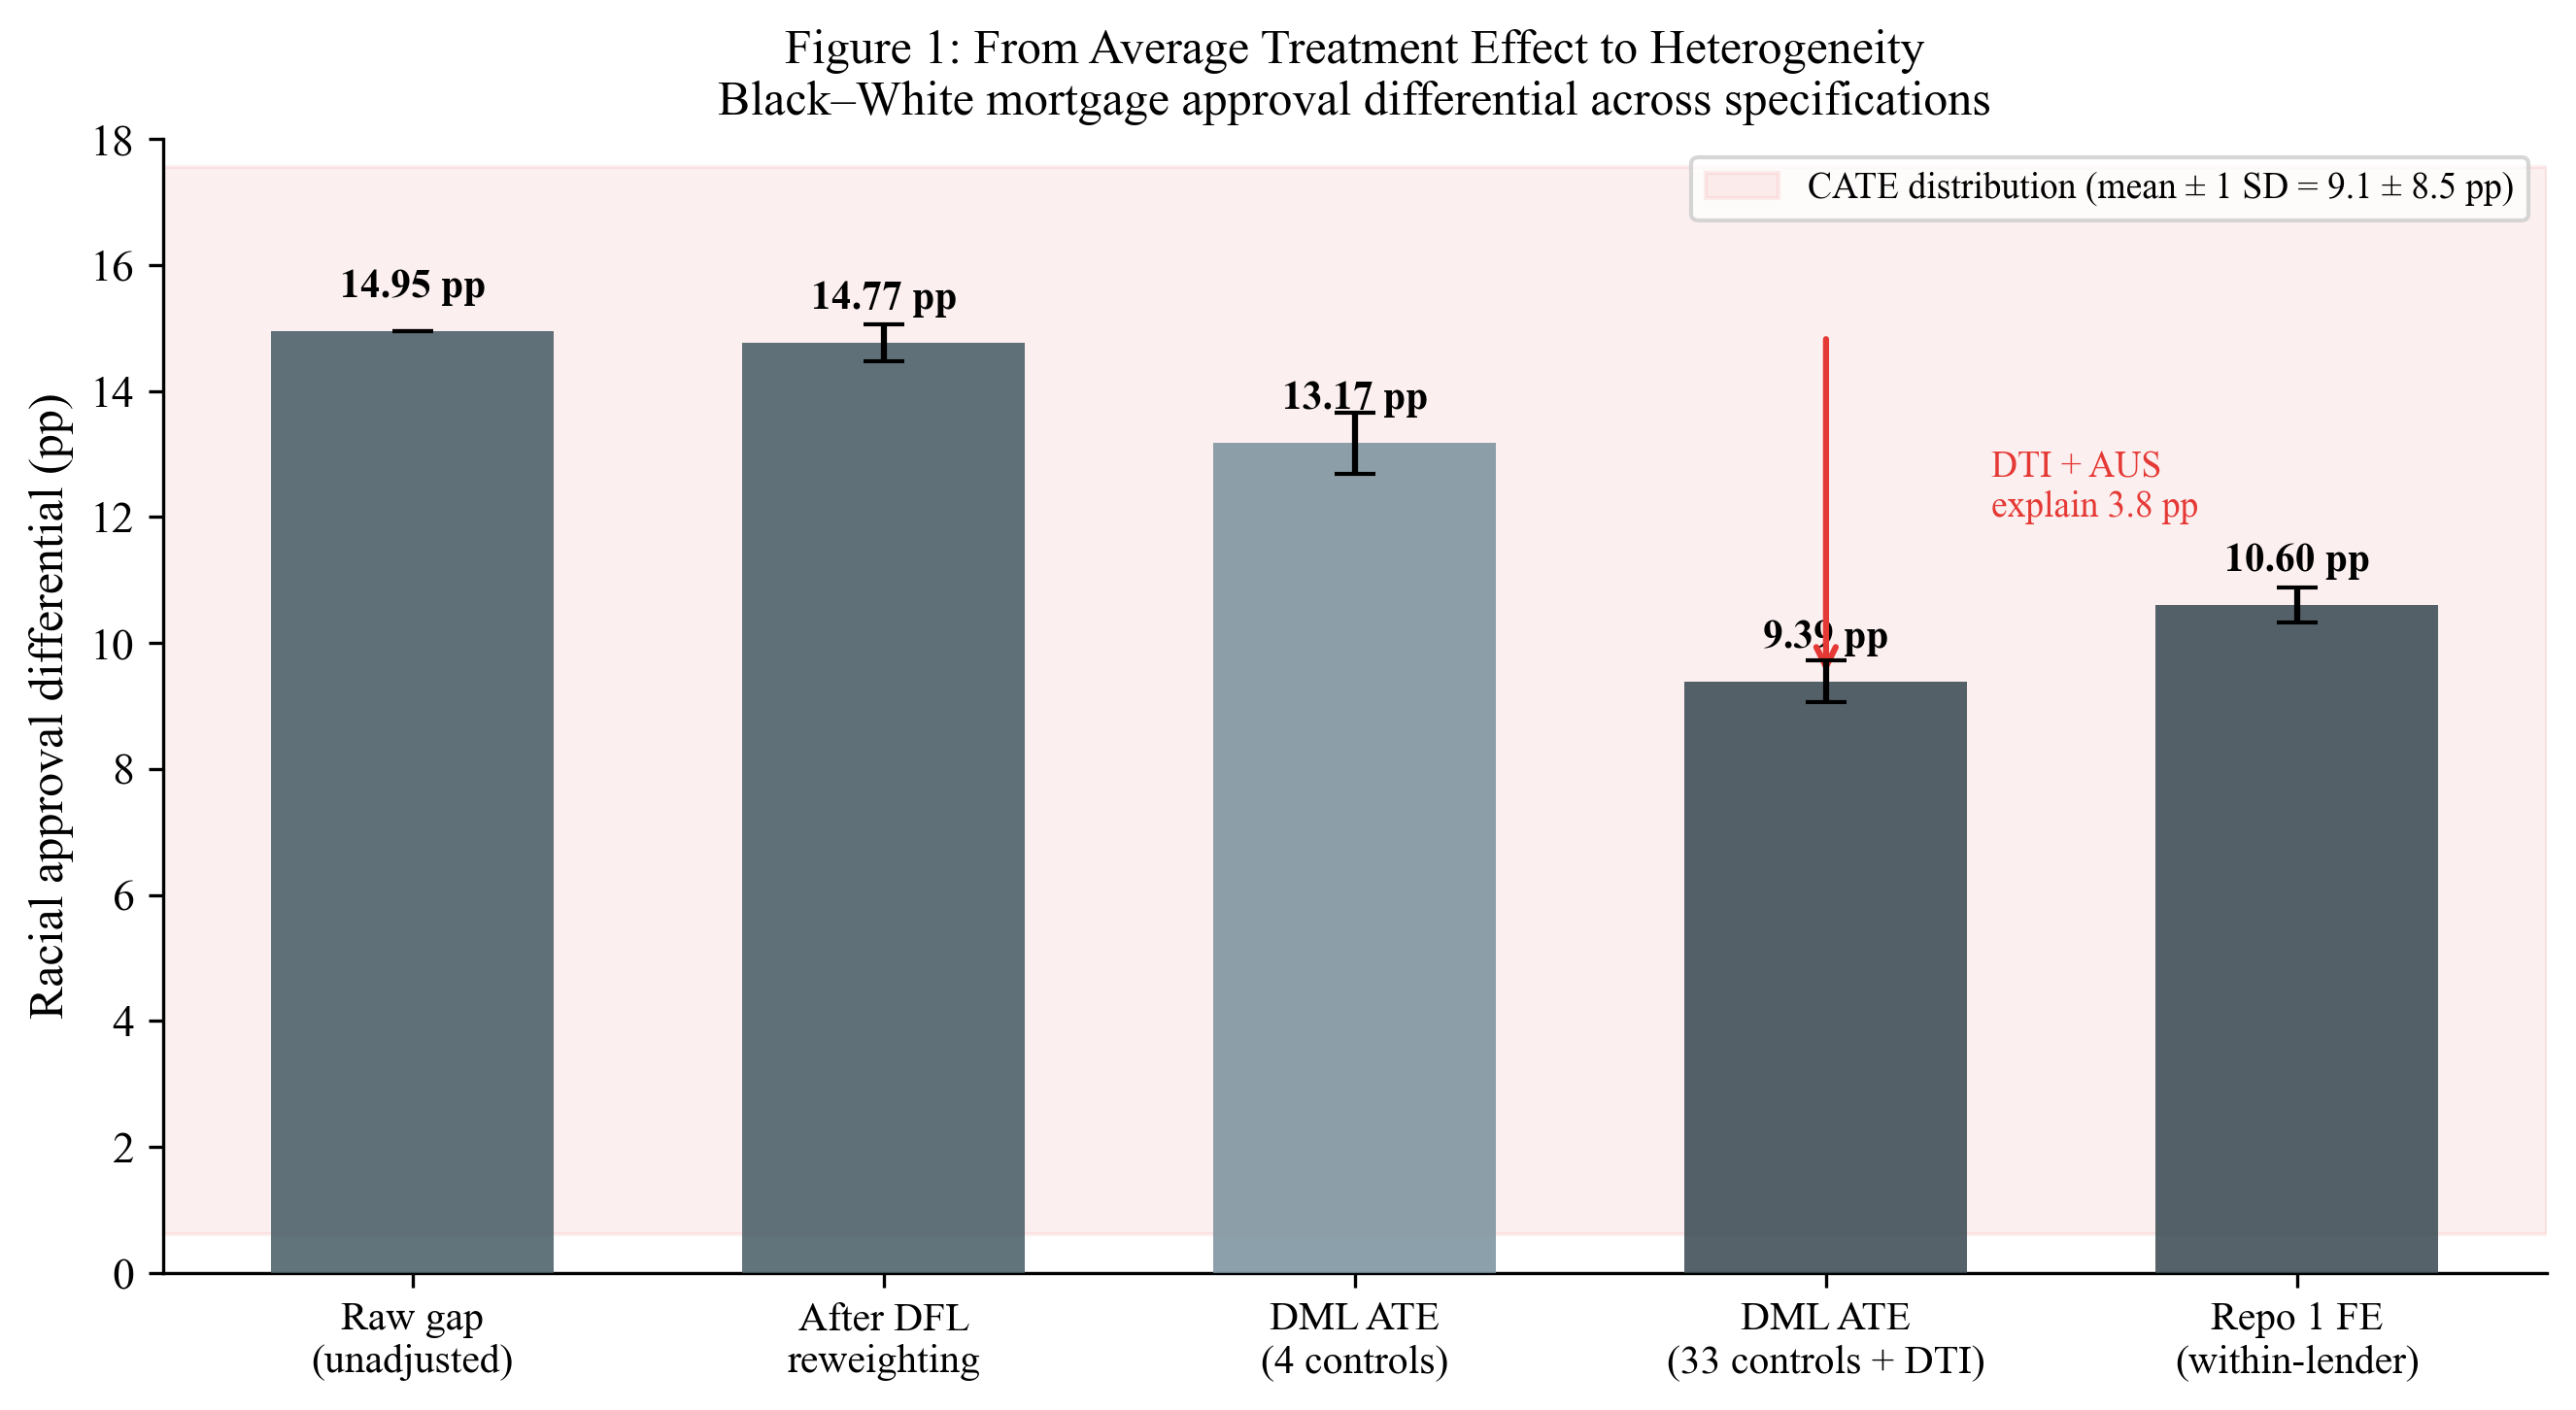

Saved: paper_fig1_ate_summary.png


In [2]:
# CELL 2 - FIGURE 1: ATE SUMMARY PANEL
# Shows the raw gap, DFL-explained, DML ATE, and the heterogeneity width
# Tells the story from Paper 1 to Paper 2 in one figure
print('Generating Figure 1: ATE Summary Panel...')

fig, ax = plt.subplots(figsize=(9, 5))

estimates = [
    ('Raw gap\n(unadjusted)',          14.95, 0,    '#455A64'),
    ('After DFL\nreweighting',         14.77, 0.15, '#455A64'),
    ('DML ATE\n(4 controls)',          13.17, 0.25, '#78909C'),
    ('DML ATE\n(33 controls + DTI)',    9.39, 0.17, NEUTRAL),
    ('Repo 1 FE\n(within-lender)',     10.60, 0.14, NEUTRAL),
]

labels  = [e[0] for e in estimates]
values  = [e[1] for e in estimates]
ses     = [e[2] for e in estimates]
colors  = [e[3] for e in estimates]
x_pos   = range(len(estimates))

bars = ax.bar(x_pos, values, color=colors, alpha=0.85, width=0.6, zorder=3)
ax.errorbar(x_pos, values,
            yerr=[1.96*s for s in ses],
            fmt='none', color='black', capsize=5, linewidth=1.5, zorder=4)

# Annotate bars
for i, (v, s) in enumerate(zip(values, ses)):
    ax.text(i, v + 0.4, f'{v:.2f} pp',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Shade the CATE distribution width
if cate_summary is not None:
    cate_mean = float(cate_summary['cate_mean_pp'].values[0])
    cate_std  = float(cate_summary['cate_std_pp'].values[0])
    ax.axhspan(abs(cate_mean) - cate_std, abs(cate_mean) + cate_std,
               alpha=0.08, color=ACCENT1,
               label=f'CATE distribution (mean ± 1 SD = {abs(cate_mean):.1f} ± {cate_std:.1f} pp)')

ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Racial approval differential (pp)', fontsize=12)
ax.set_title(
    'Figure 1: From Average Treatment Effect to Heterogeneity\n'
    'Black–White mortgage approval differential across specifications',
    fontsize=12
)
ax.set_ylim(0, 18)
ax.legend(fontsize=9, loc='upper right')
ax.axhline(0, color='black', linewidth=0.5)

# Arrow annotation
ax.annotate('', xy=(3, 9.39), xytext=(3, 14.95),
            arrowprops=dict(arrowstyle='->', color=ACCENT1, lw=1.5))
ax.text(3.35, 12, 'DTI + AUS\nexplain 3.8 pp', fontsize=9, color=ACCENT1)

plt.tight_layout()
out = PAPER_DIR / 'paper_fig1_ate_summary.png'
plt.savefig(out, dpi=300)
plt.show()
print(f'Saved: {out.name}')

Generating Figure 2: CATE Distribution...


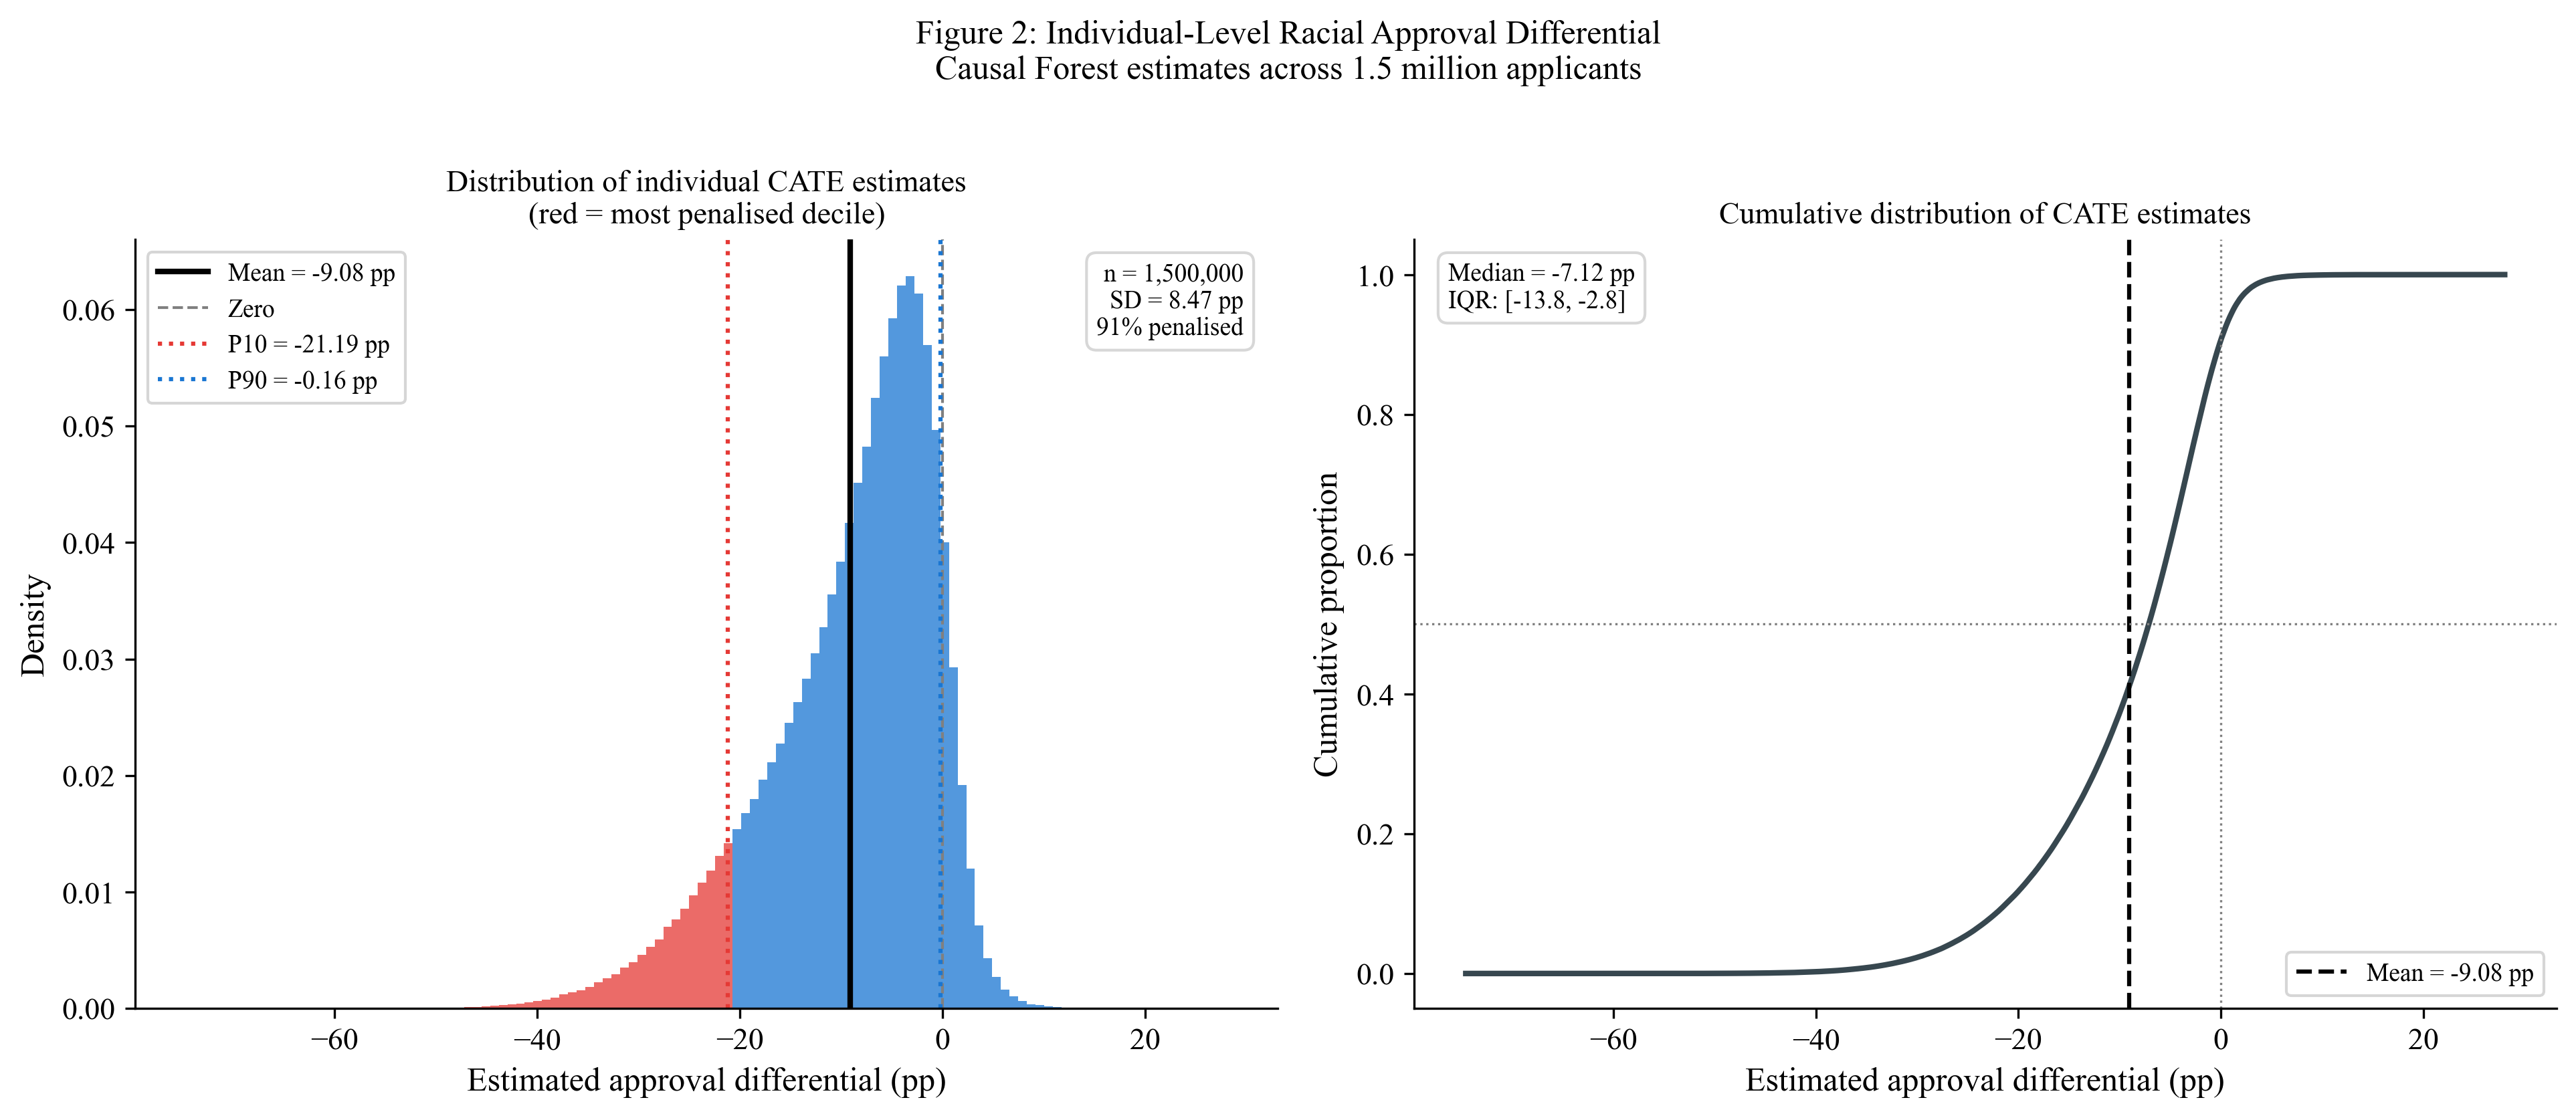

Saved: paper_fig2_cate_distribution.png


In [3]:
# CELL 3 - FIGURE 2: CATE DISTRIBUTION (MAIN RESULT)
print('Generating Figure 2: CATE Distribution...')

cate_pp = cate_df['cate_pp'].values

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Left: histogram
ax = axes[0]
n, bins, patches = ax.hist(cate_pp, bins=120, color=ACCENT2, alpha=0.75,
                            edgecolor='none', density=True)

# Color the left tail (most penalised) in red
p10 = np.percentile(cate_pp, 10)
for patch, left in zip(patches, bins[:-1]):
    if left < p10:
        patch.set_facecolor(ACCENT1)
        patch.set_alpha(0.75)

ax.axvline(np.mean(cate_pp), color='black', linewidth=2,
           label=f'Mean = {np.mean(cate_pp):.2f} pp')
ax.axvline(0, color='grey', linewidth=1, linestyle='--', label='Zero')
ax.axvline(p10, color=ACCENT1, linewidth=1.5, linestyle=':',
           label=f'P10 = {p10:.2f} pp')
ax.axvline(np.percentile(cate_pp, 90), color=ACCENT2, linewidth=1.5, linestyle=':',
           label=f'P90 = {np.percentile(cate_pp,90):.2f} pp')

ax.set_xlabel('Estimated approval differential (pp)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Distribution of individual CATE estimates\n'
             '(red = most penalised decile)', fontsize=11)
ax.legend(fontsize=9)
ax.text(0.97, 0.97,
        f'n = {len(cate_pp):,}\n'
        f'SD = {np.std(cate_pp):.2f} pp\n'
        f'{100*(cate_pp<0).mean():.0f}% penalised',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor='lightgrey', alpha=0.9))

# Right: CDF
ax = axes[1]
sorted_cate = np.sort(cate_pp)
cdf = np.arange(1, len(sorted_cate)+1) / len(sorted_cate)
ax.plot(sorted_cate, cdf, color=NEUTRAL, linewidth=2)
ax.axvline(np.mean(cate_pp), color='black', linewidth=1.5, linestyle='--',
           label=f'Mean = {np.mean(cate_pp):.2f} pp')
ax.axhline(0.5, color='grey', linewidth=0.8, linestyle=':')
ax.axvline(0, color='grey', linewidth=0.8, linestyle=':')
ax.set_xlabel('Estimated approval differential (pp)', fontsize=12)
ax.set_ylabel('Cumulative proportion', fontsize=12)
ax.set_title('Cumulative distribution of CATE estimates', fontsize=11)
ax.legend(fontsize=9)
ax.text(0.03, 0.97,
        f'Median = {np.median(cate_pp):.2f} pp\nIQR: [{np.percentile(cate_pp,25):.1f}, {np.percentile(cate_pp,75):.1f}]',
        transform=ax.transAxes, ha='left', va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor='lightgrey', alpha=0.9))

plt.suptitle('Figure 2: Individual-Level Racial Approval Differential\n'
             'Causal Forest estimates across 1.5 million applicants',
             fontsize=12, y=1.01)
plt.tight_layout()
out = PAPER_DIR / 'paper_fig2_cate_distribution.png'
plt.savefig(out, dpi=300)
plt.show()
print(f'Saved: {out.name}')

Generating Figure 3: Subgroup Results...


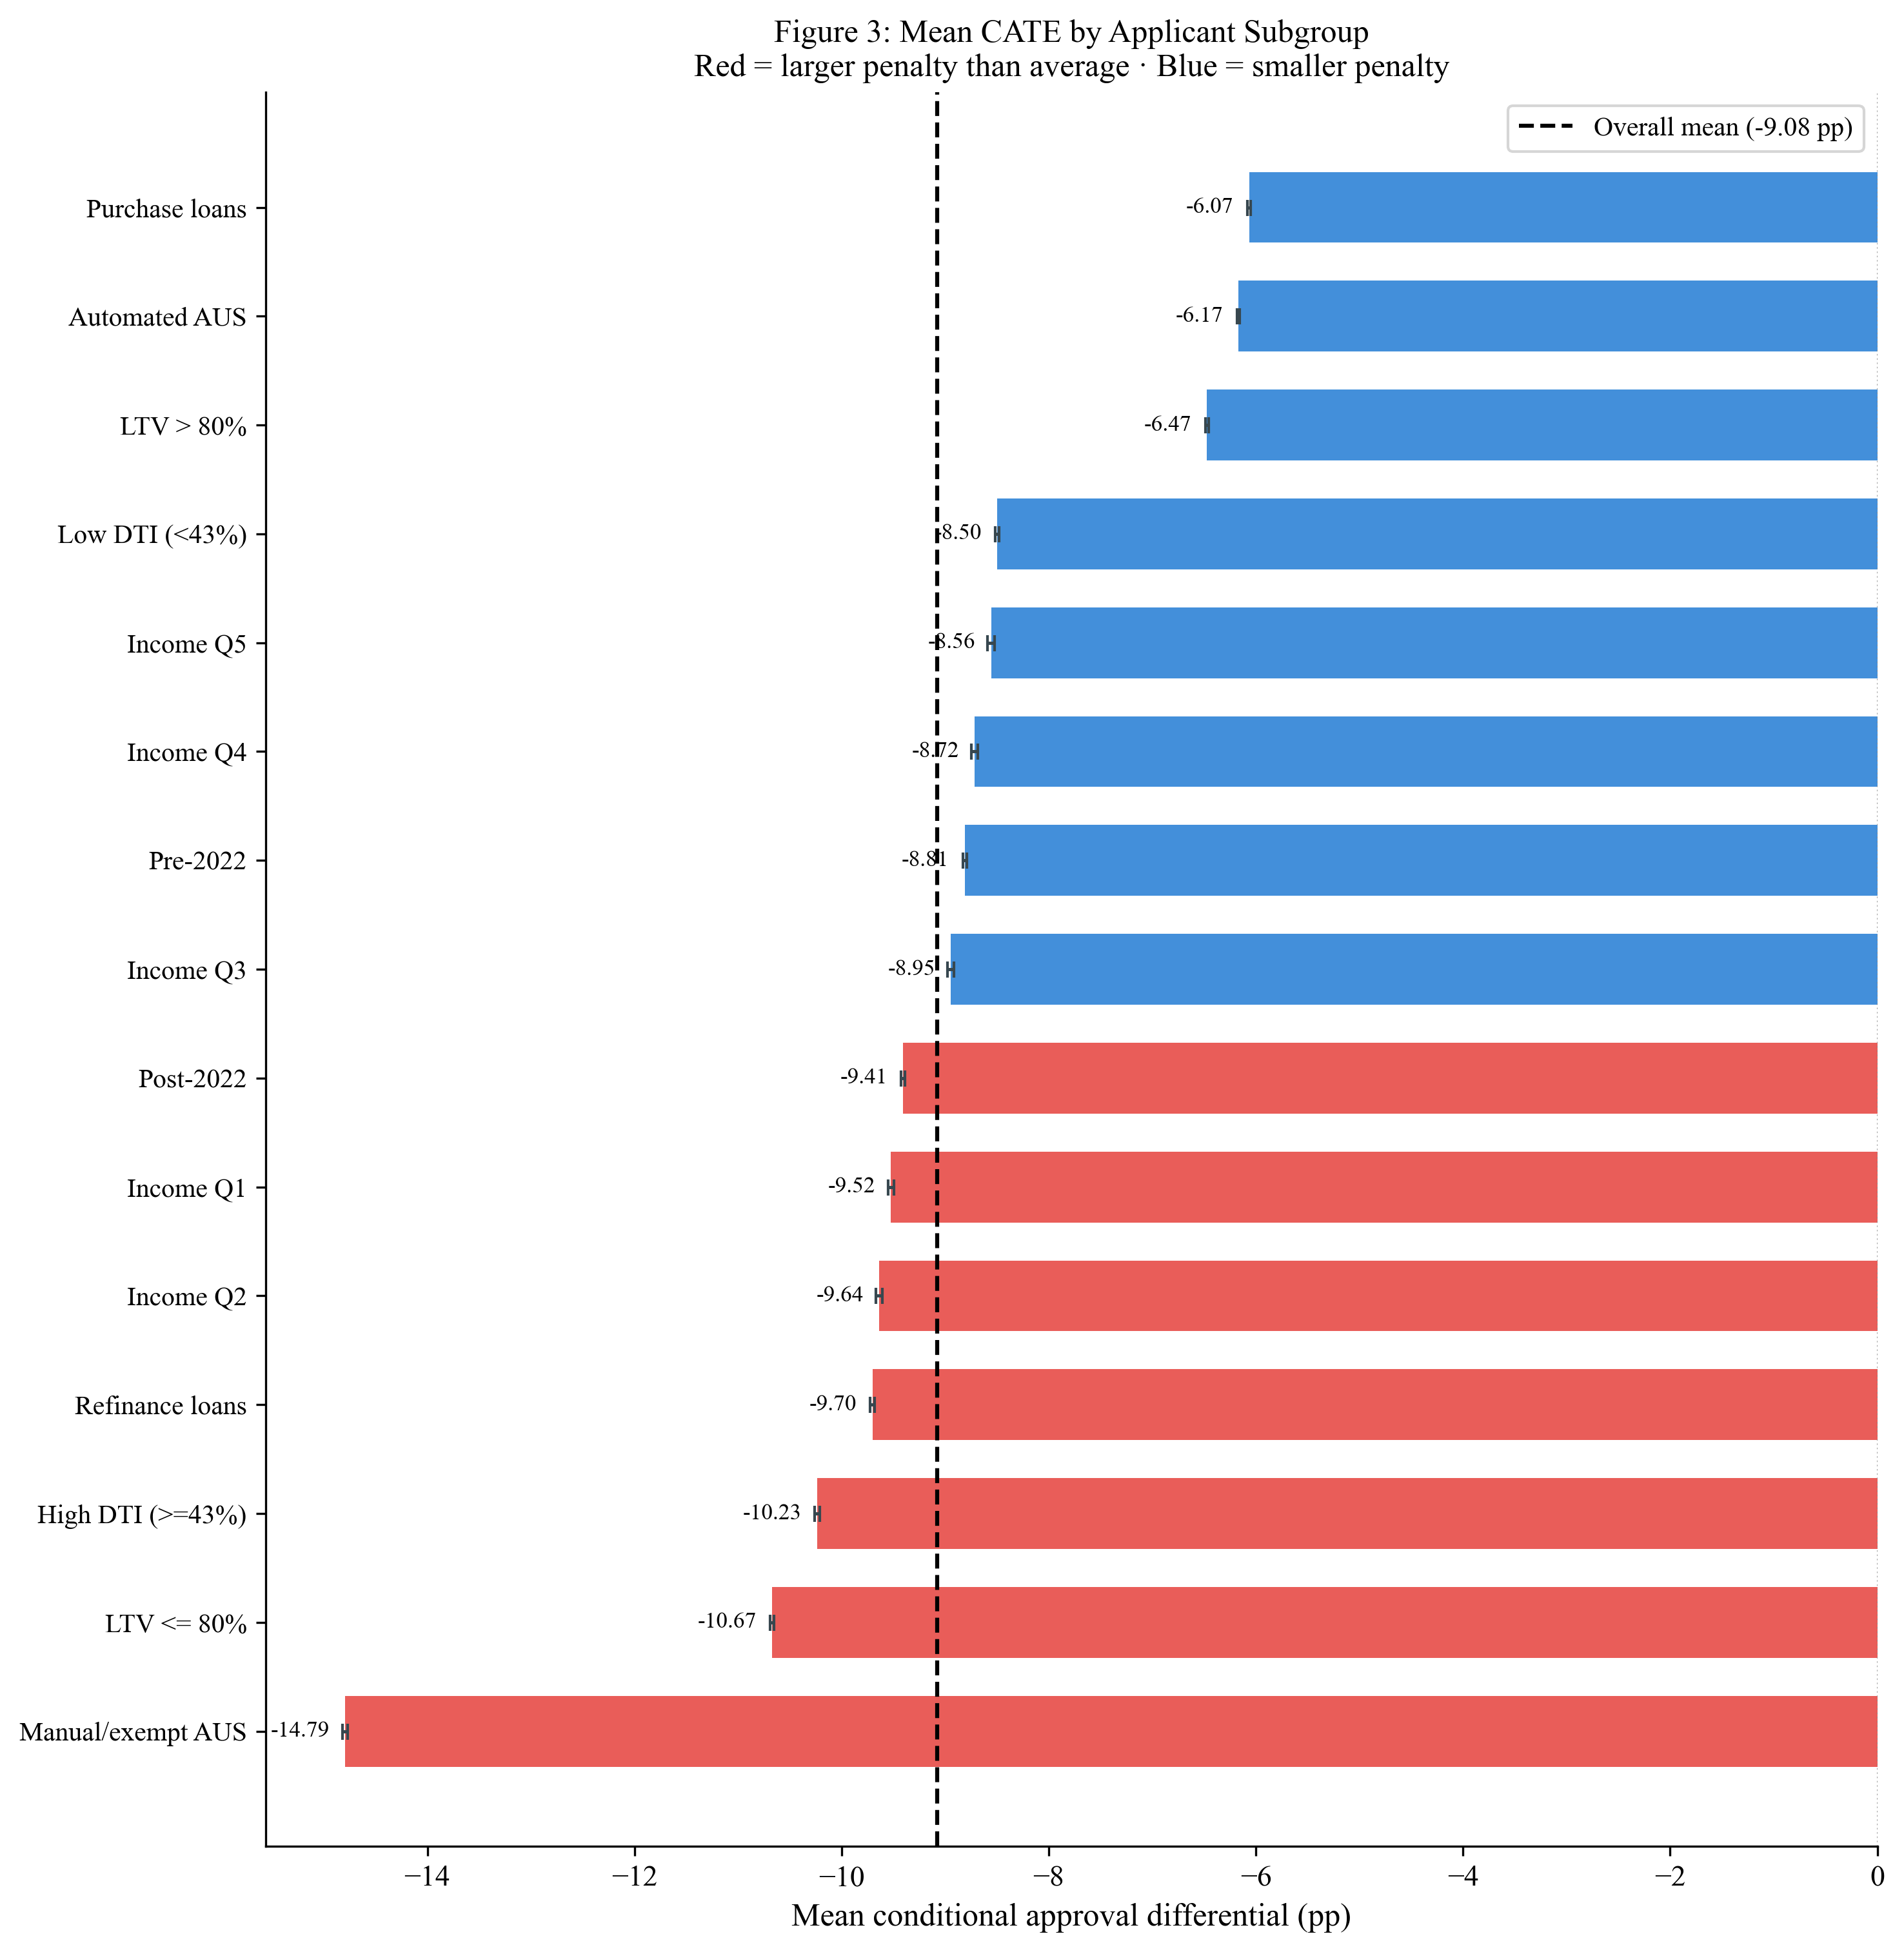

Saved: paper_fig3_subgroup_results.png


In [4]:
# CELL 4 - FIGURE 3: SUBGROUP RESULTS
print('Generating Figure 3: Subgroup Results...')

if cate_subgroups is not None:
    # Select and order subgroups
    key_groups = [
        'Income Q1', 'Income Q2', 'Income Q3', 'Income Q4', 'Income Q5',
        'LTV <= 80%', 'LTV > 80%',
        'Purchase loans', 'Refinance loans',
        'Automated AUS', 'Manual/exempt AUS',
        'Low DTI (<43%)', 'High DTI (>=43%)',
        'Pre-2022', 'Post-2022',
    ]
    # Filter to available subgroups
    sg = cate_subgroups[cate_subgroups['subgroup'].isin(key_groups)].copy()
    if len(sg) == 0:
        sg = cate_subgroups.copy()

    sg = sg.sort_values('mean_cate')
    overall_mean = float(cate_summary['cate_mean_pp'].values[0]) if cate_summary is not None else -9.08

    fig, ax = plt.subplots(figsize=(10, 0.55*len(sg) + 2))

    colors = [ACCENT1 if v < overall_mean else ACCENT2
              for v in sg['mean_cate']]

    ax.barh(range(len(sg)), sg['mean_cate'], color=colors, alpha=0.82,
            height=0.65)
    ax.errorbar(sg['mean_cate'], range(len(sg)),
                xerr=1.96*sg['se'],
                fmt='none', color='#37474F', capsize=3, linewidth=1.2)

    ax.axvline(overall_mean, color='black', linewidth=1.5, linestyle='--',
               label=f'Overall mean ({overall_mean:.2f} pp)', zorder=5)
    ax.axvline(0, color='grey', linewidth=0.6, linestyle=':')

    ax.set_yticks(range(len(sg)))
    ax.set_yticklabels(sg['subgroup'], fontsize=10)
    ax.set_xlabel('Mean conditional approval differential (pp)', fontsize=12)
    ax.set_title('Figure 3: Mean CATE by Applicant Subgroup\n'
                 'Red = larger penalty than average · Blue = smaller penalty',
                 fontsize=12)
    ax.legend(fontsize=10)

    for i, (_, row) in enumerate(sg.iterrows()):
        ax.text(row['mean_cate'] - 0.15, i,
                f"{row['mean_cate']:.2f}",
                va='center', ha='right', fontsize=8.5)

    plt.tight_layout()
    out = PAPER_DIR / 'paper_fig3_subgroup_results.png'
    plt.savefig(out, dpi=300)
    plt.show()
    print(f'Saved: {out.name}')
else:
    print('nb21_cate_subgroups.csv not found — skipping Figure 3')

Generating Figure 4: SHAP Attribution...


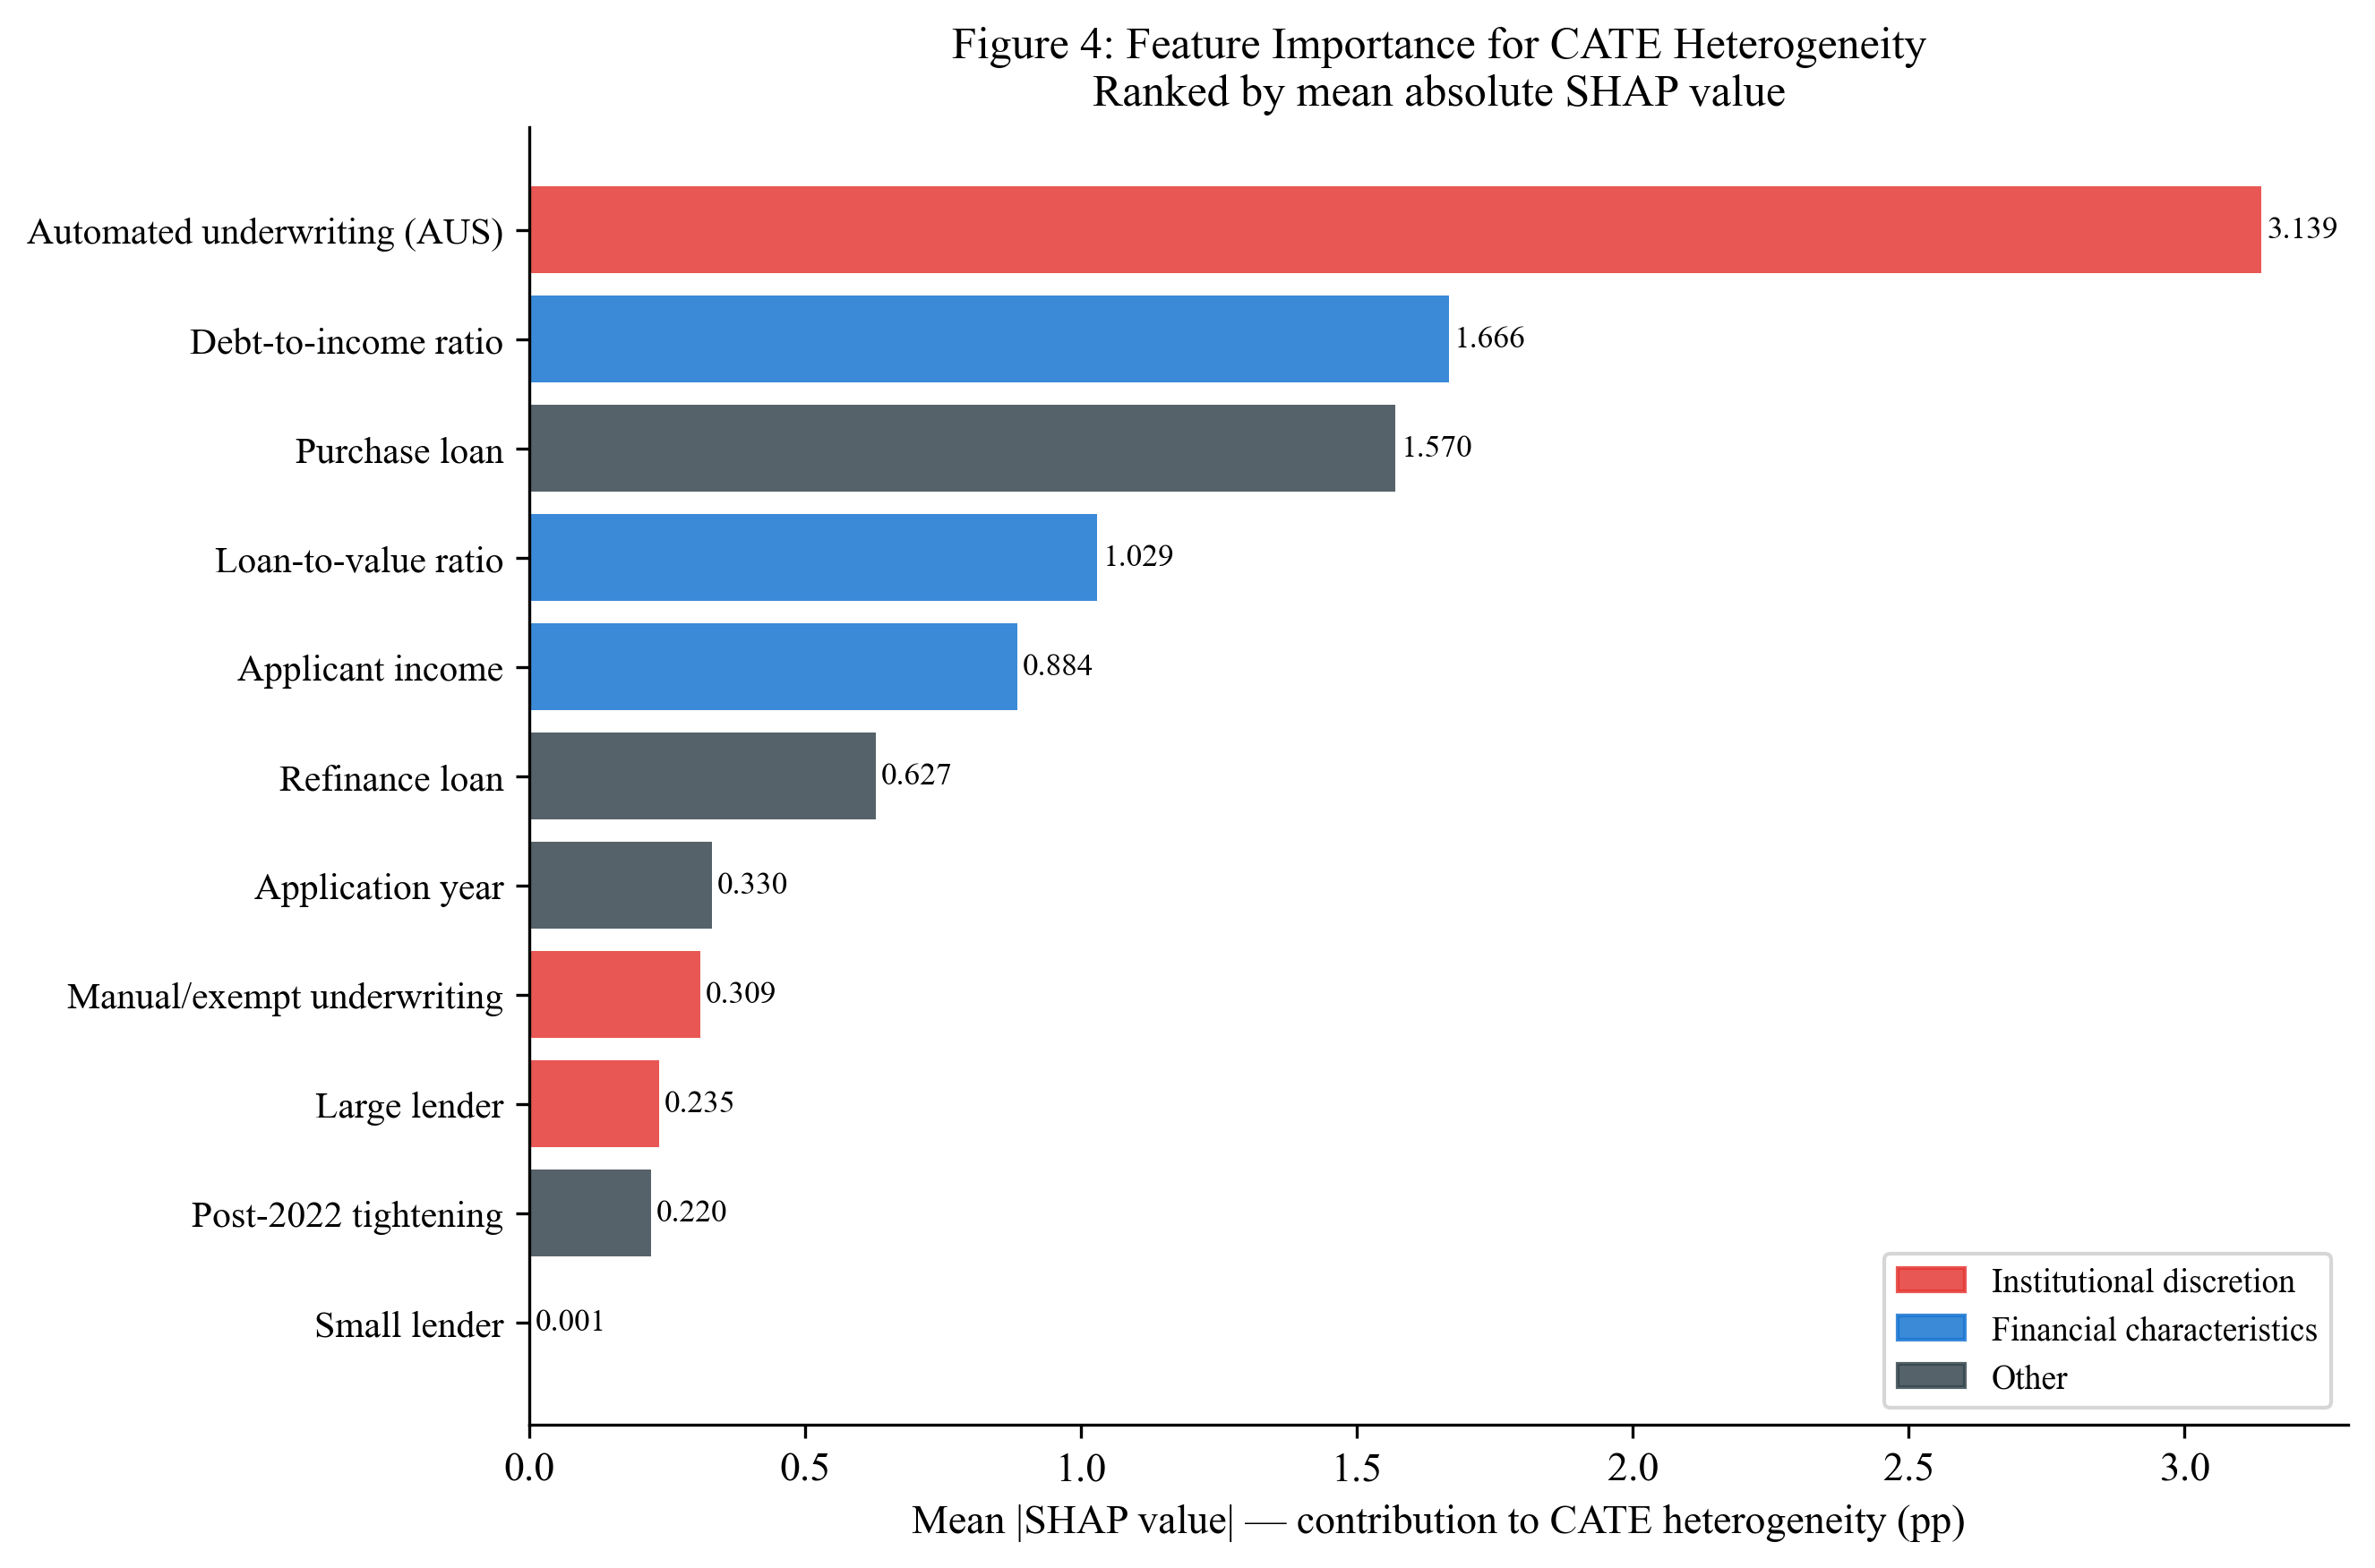

Saved: paper_fig4_shap_attribution.png


In [5]:
# CELL 5 - FIGURE 4: SHAP ATTRIBUTION (CLEAN VERSION)
print('Generating Figure 4: SHAP Attribution...')

if shap_imp is not None:
    top_n = min(12, len(shap_imp))
    plot_shap = shap_imp.head(top_n).sort_values('mean_abs_shap').copy()

    FNAME = {
        'aus_automated': 'Automated underwriting (AUS)',
        'aus_exempt': 'Manual/exempt underwriting',
        'ltv': 'Loan-to-value ratio',
        'income': 'Applicant income',
        'log_income': 'Log income',
        'dti_midpoint': 'Debt-to-income ratio',
        'above_pmi': 'Above PMI threshold',
        'near_pmi_threshold': 'Near PMI threshold',
        'post_tightening': 'Post-2022 tightening',
        'purpose_purchase': 'Purchase loan',
        'purpose_refi': 'Refinance loan',
        'lender_large': 'Large lender',
        'year': 'Application year',
    }

    if 'display_name' in plot_shap.columns:
        names = plot_shap['display_name'].values
    else:
        names = [FNAME.get(f, f) for f in plot_shap['feature'].values]

    discretion = {'aus_exempt', 'aus_automated', 'lender_large', 'lender_small', 'lender_mid'}
    financial  = {'ltv', 'income', 'log_income', 'dti_midpoint', 'dti_high',
                  'loan_amount', 'log_loan_amount'}
    colors = []
    for f in plot_shap['feature']:
        if f in discretion:
            colors.append(ACCENT1)
        elif f in financial:
            colors.append(ACCENT2)
        else:
            colors.append(NEUTRAL)

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(range(top_n), plot_shap['mean_abs_shap'], color=colors, alpha=0.85)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(names, fontsize=10)
    ax.set_xlabel('Mean |SHAP value| — contribution to CATE heterogeneity (pp)',
                  fontsize=11)
    ax.set_title('Figure 4: Feature Importance for CATE Heterogeneity\n'
                 'Ranked by mean absolute SHAP value', fontsize=12)

    for i, (_, row) in enumerate(plot_shap.iterrows()):
        ax.text(row['mean_abs_shap'] + 0.01, i,
                f"{row['mean_abs_shap']:.3f}", va='center', fontsize=8.5)

    ax.legend(handles=[
        mpatches.Patch(color=ACCENT1, alpha=0.85, label='Institutional discretion'),
        mpatches.Patch(color=ACCENT2, alpha=0.85, label='Financial characteristics'),
        mpatches.Patch(color=NEUTRAL, alpha=0.85, label='Other'),
    ], fontsize=9, loc='lower right')

    plt.tight_layout()
    out = PAPER_DIR / 'paper_fig4_shap_attribution.png'
    plt.savefig(out, dpi=300)
    plt.show()
    print(f'Saved: {out.name}')
else:
    print('nb22_shap_importance.csv not found — skipping Figure 4')

Generating Figure 5: Disparity Map...


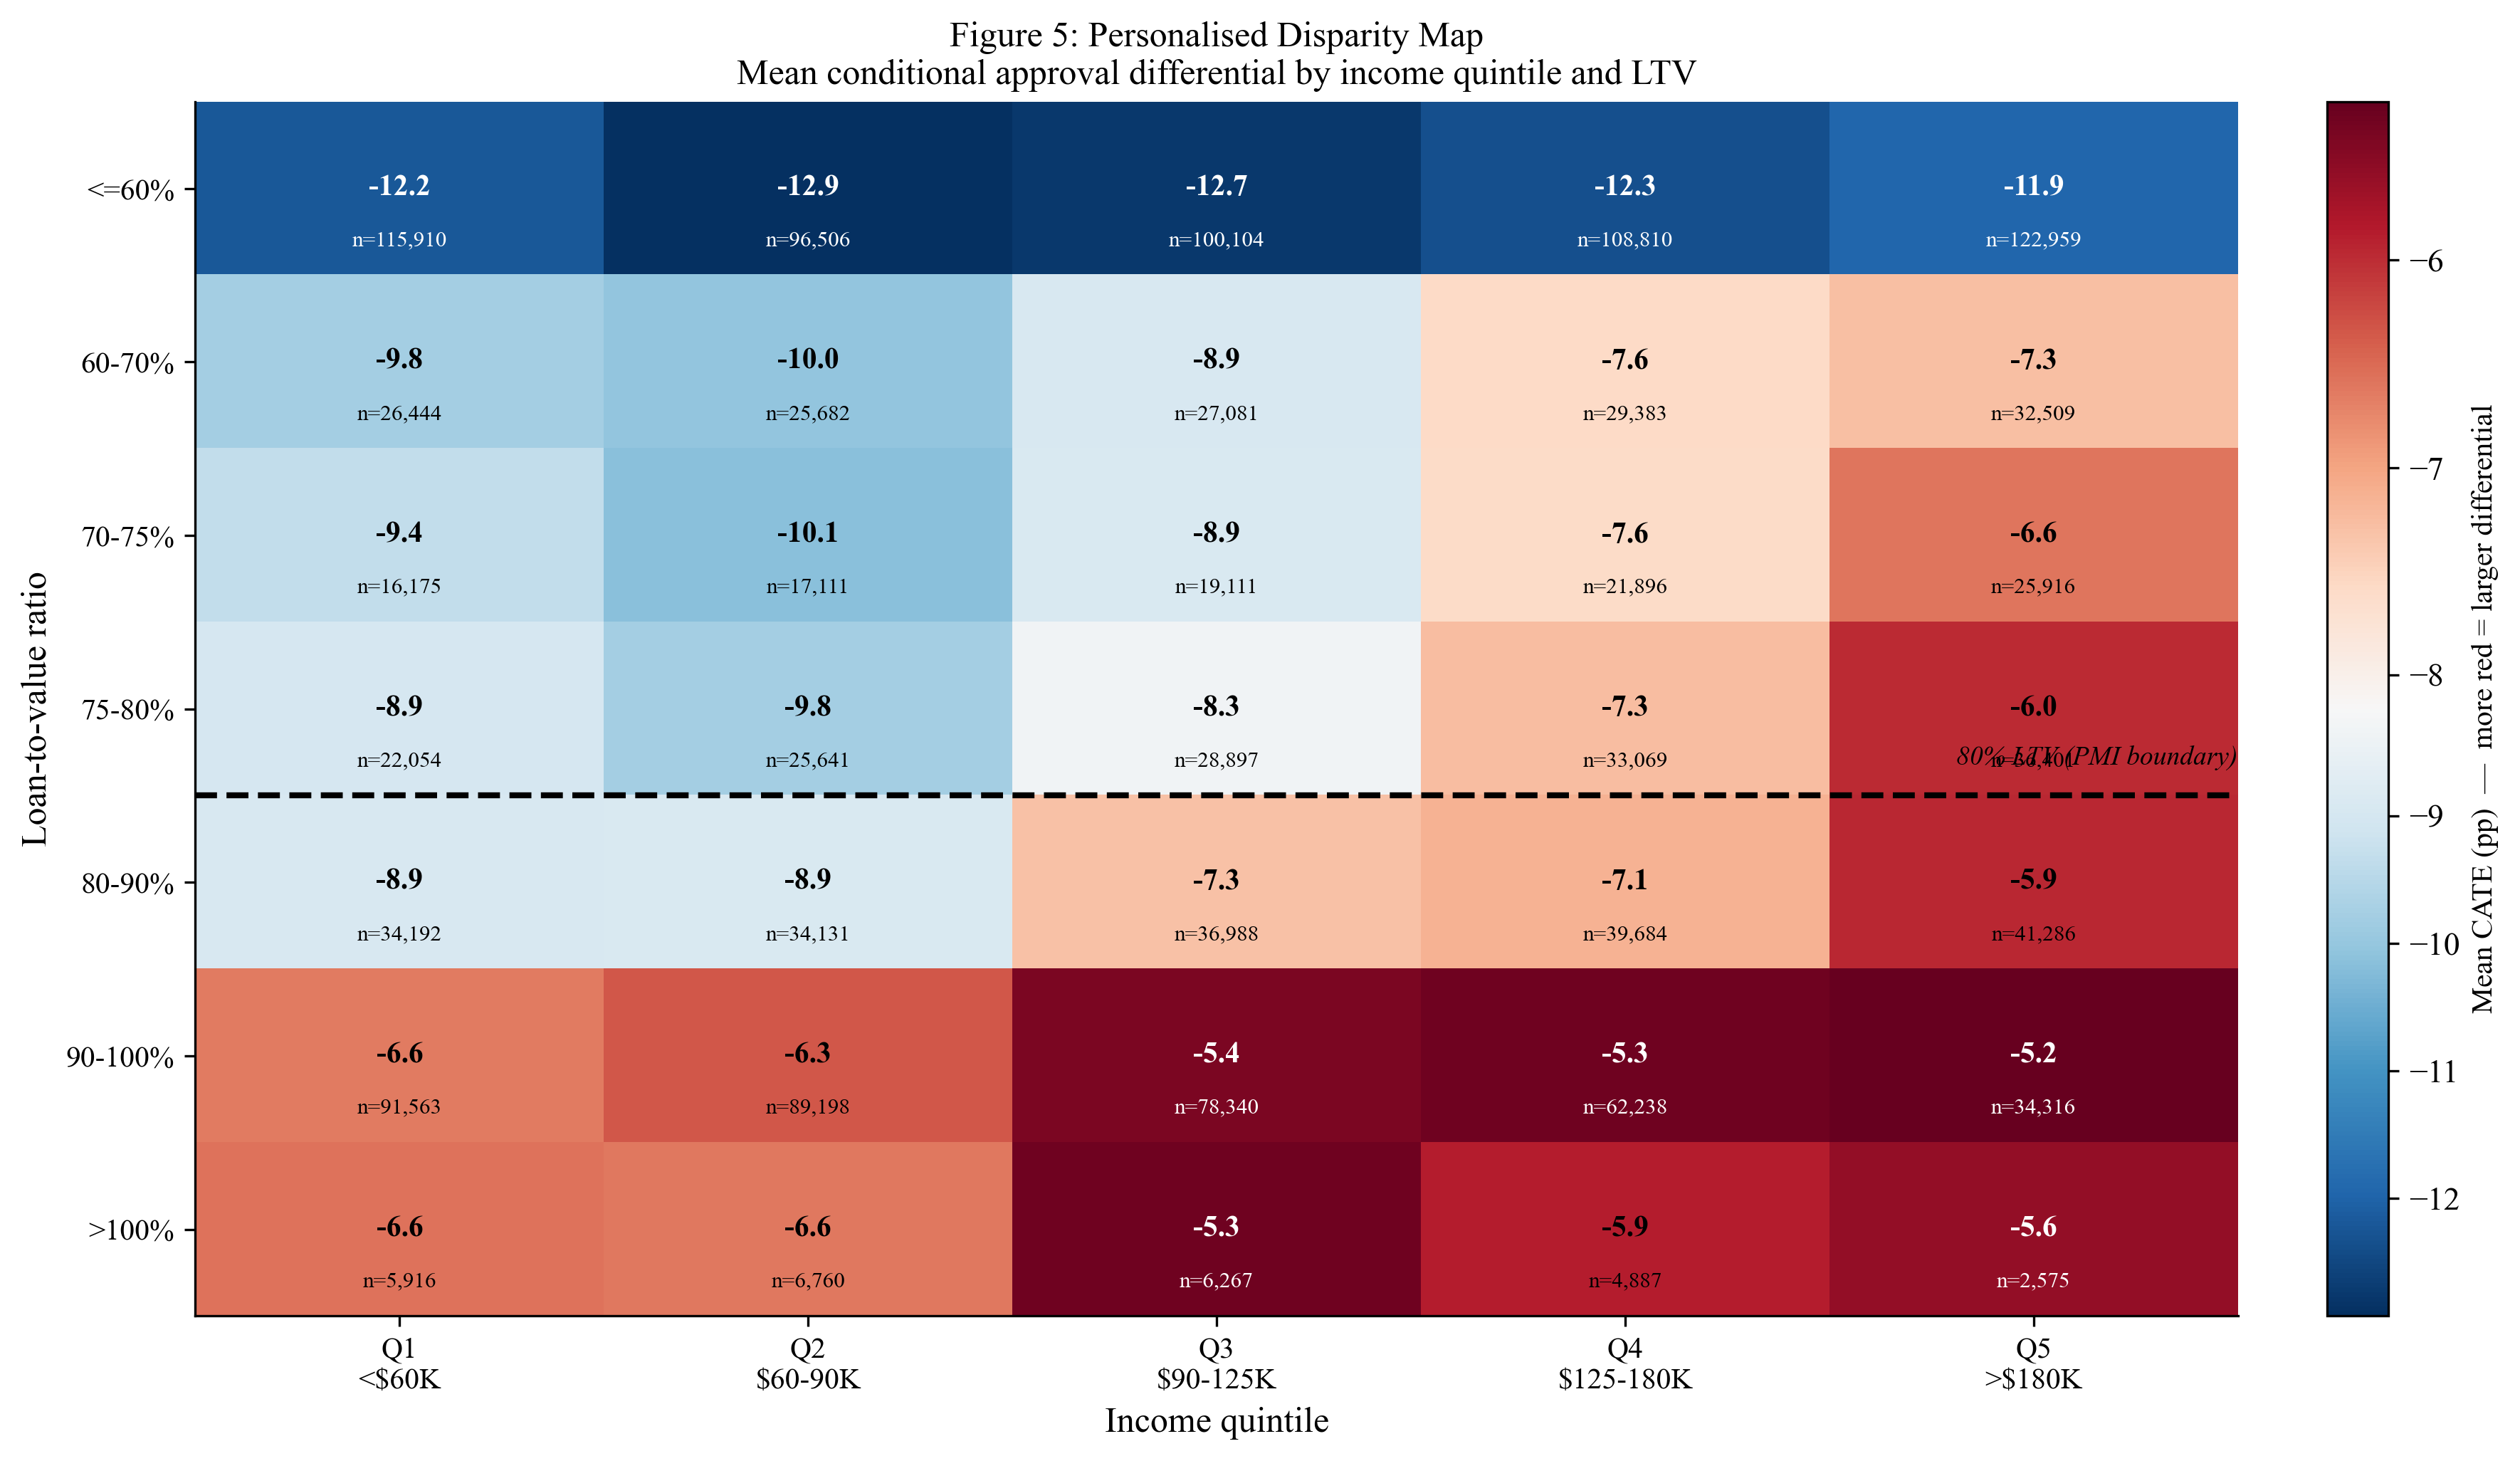

Saved: paper_fig5_disparity_map.png


In [6]:
# CELL 6 - FIGURE 5: DISPARITY MAP (INCOME x LTV)
print('Generating Figure 5: Disparity Map...')

if disparity_cells is not None and len(disparity_cells) > 0:
    # Pivot
    disp = disparity_cells.copy()
    disp['income_q'] = disp['income_q'].str.replace('\\n', '\n', regex=False)

    try:
        hmap = disp.pivot(index='ltv_bin', columns='income_q', values='mean_cate')
        hmap_n = disp.pivot(index='ltv_bin', columns='income_q', values='n')

        ltv_order = ['<=60%', '60-70%', '70-75%', '75-80%', '80-90%', '90-100%', '>100%']
        ltv_order = [l for l in ltv_order if l in hmap.index]
        hmap   = hmap.reindex(ltv_order)
        hmap_n = hmap_n.reindex(ltv_order)

        fig, ax = plt.subplots(figsize=(12, 7))
        vmin = hmap.values.min()
        vmax = hmap.values.max()
        vctr = hmap.values.mean()
        norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vctr, vmax=vmax)

        im = ax.imshow(hmap.values, cmap='RdBu_r', norm=norm, aspect='auto')

        for i in range(len(hmap.index)):
            for j in range(len(hmap.columns)):
                v = hmap.values[i, j]
                n_c = hmap_n.values[i, j]
                if not np.isnan(v):
                    tcol = 'white' if abs(v - vctr) > 2.5 else 'black'
                    ax.text(j, i, f'{v:.1f}', ha='center', va='center',
                            fontsize=10, fontweight='bold', color=tcol)
                    ax.text(j, i+0.30, f'n={int(n_c):,}', ha='center', va='center',
                            fontsize=7.5, color=tcol)

        ax.set_xticks(range(len(hmap.columns)))
        ax.set_xticklabels(hmap.columns, fontsize=10)
        ax.set_yticks(range(len(hmap.index)))
        ax.set_yticklabels(hmap.index, fontsize=10)
        ax.set_xlabel('Income quintile', fontsize=12)
        ax.set_ylabel('Loan-to-value ratio', fontsize=12)

        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('Mean CATE (pp)  —  more red = larger differential',
                       fontsize=10)

        # PMI boundary
        try:
            pmi_row = list(hmap.index).index('80-90%') - 0.5
            ax.axhline(pmi_row, color='black', linewidth=2, linestyle='--')
            ax.text(len(hmap.columns)-0.5, pmi_row-0.18,
                    '80% LTV (PMI boundary)', fontsize=9,
                    ha='right', style='italic')
        except (ValueError, IndexError):
            pass

        ax.set_title(
            'Figure 5: Personalised Disparity Map\n'
            'Mean conditional approval differential by income quintile and LTV',
            fontsize=12
        )
        plt.tight_layout()
        out = PAPER_DIR / 'paper_fig5_disparity_map.png'
        plt.savefig(out, dpi=300)
        plt.show()
        print(f'Saved: {out.name}')
    except Exception as e:
        print(f'Could not generate disparity map: {e}')
else:
    print('nb23_disparity_cells.csv not found — skipping Figure 5')

Generating Figures 6 and 7...


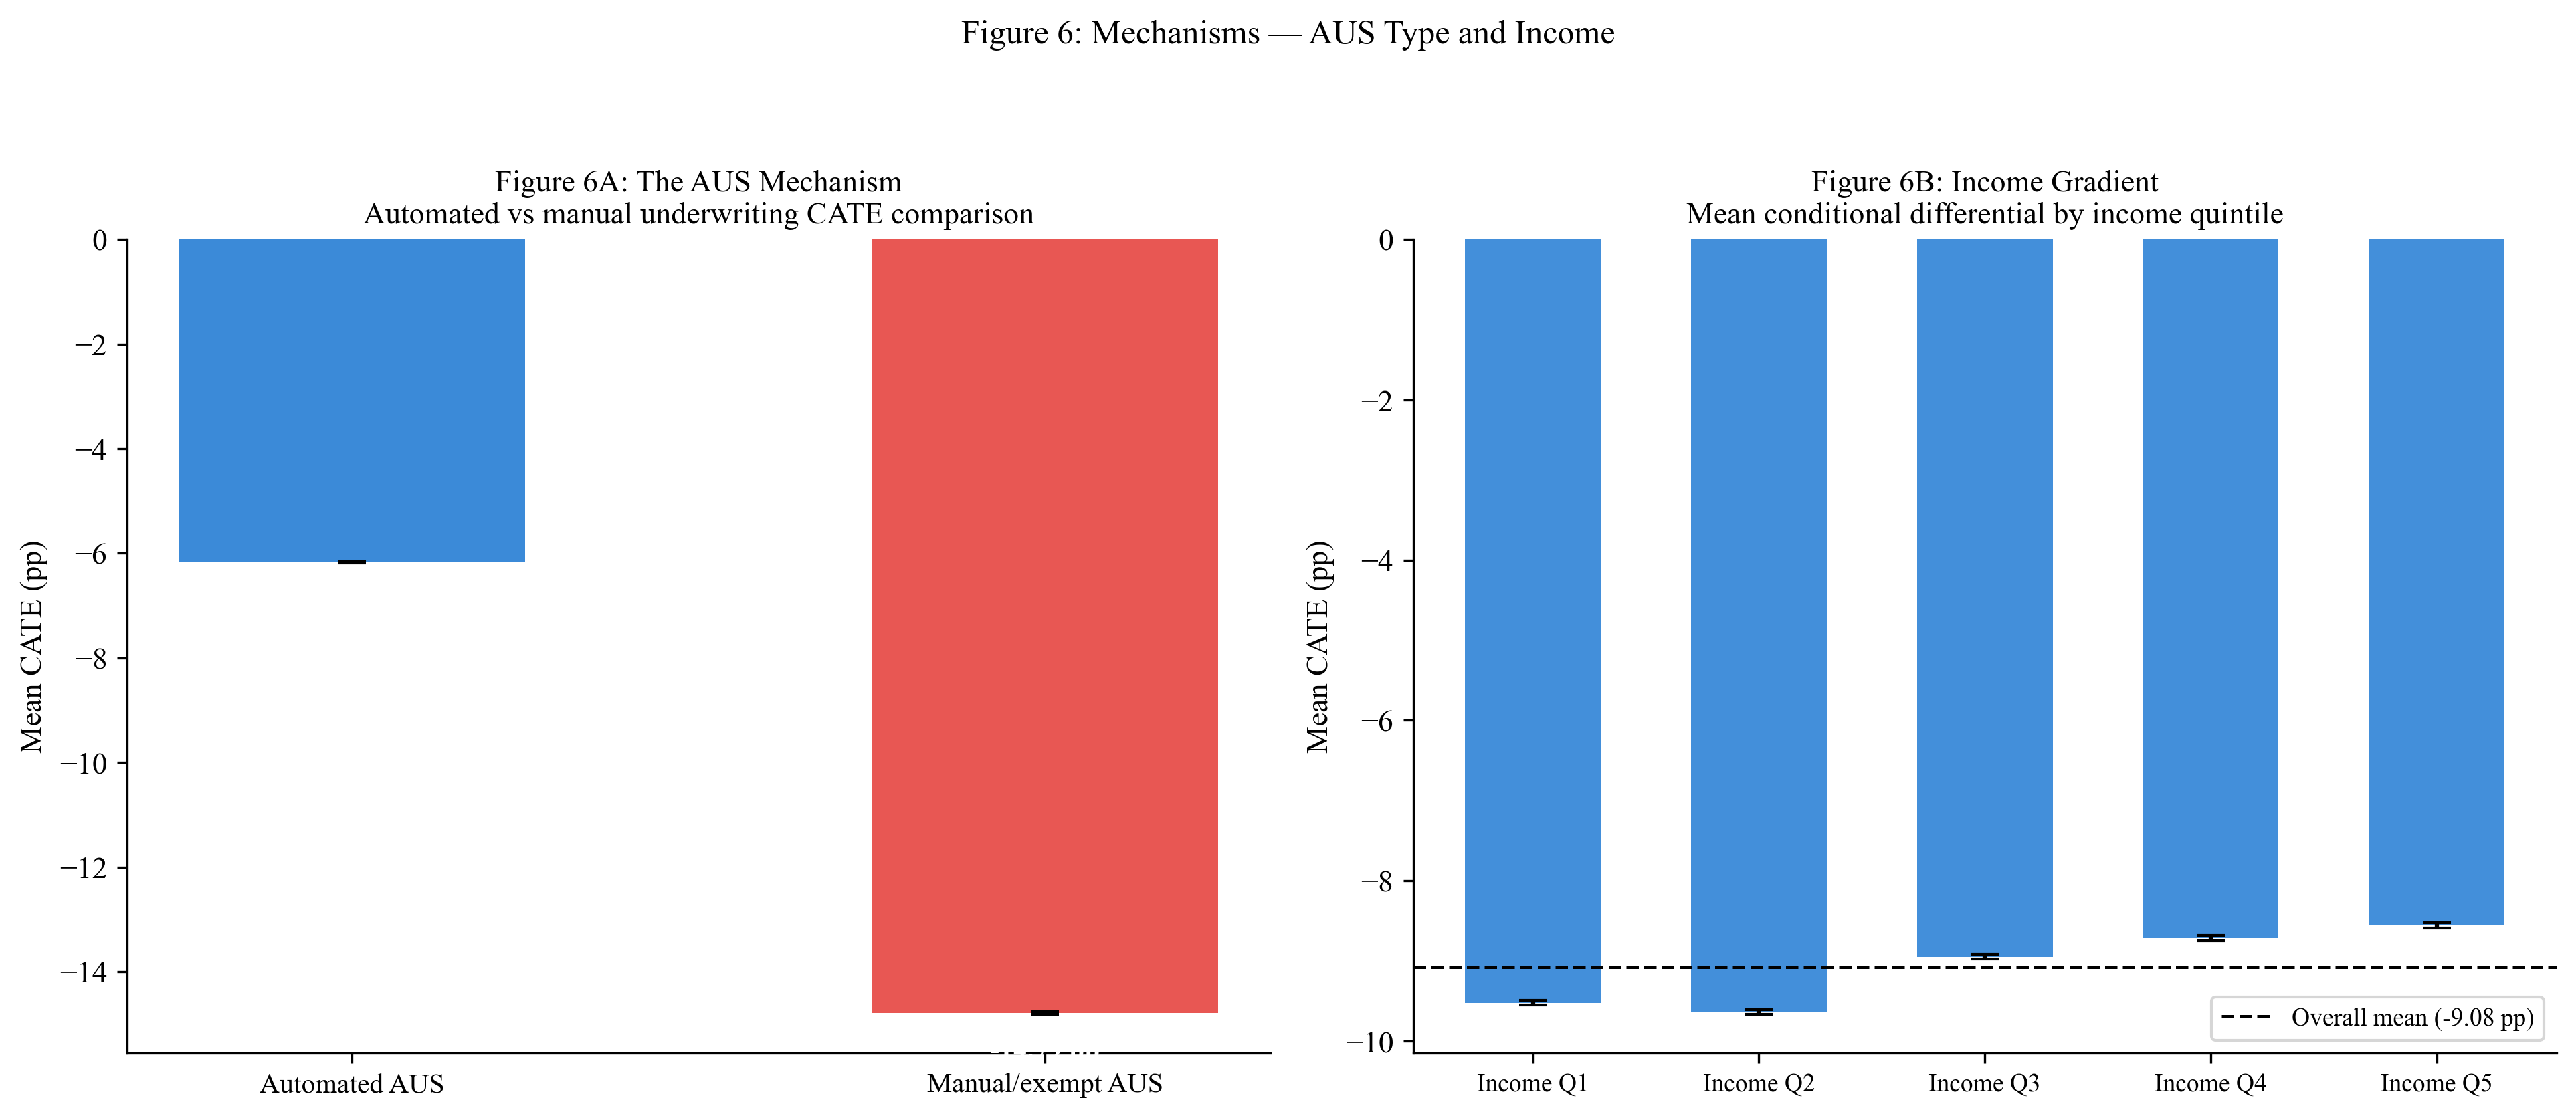

Saved: paper_fig6_aus_mechanism.png


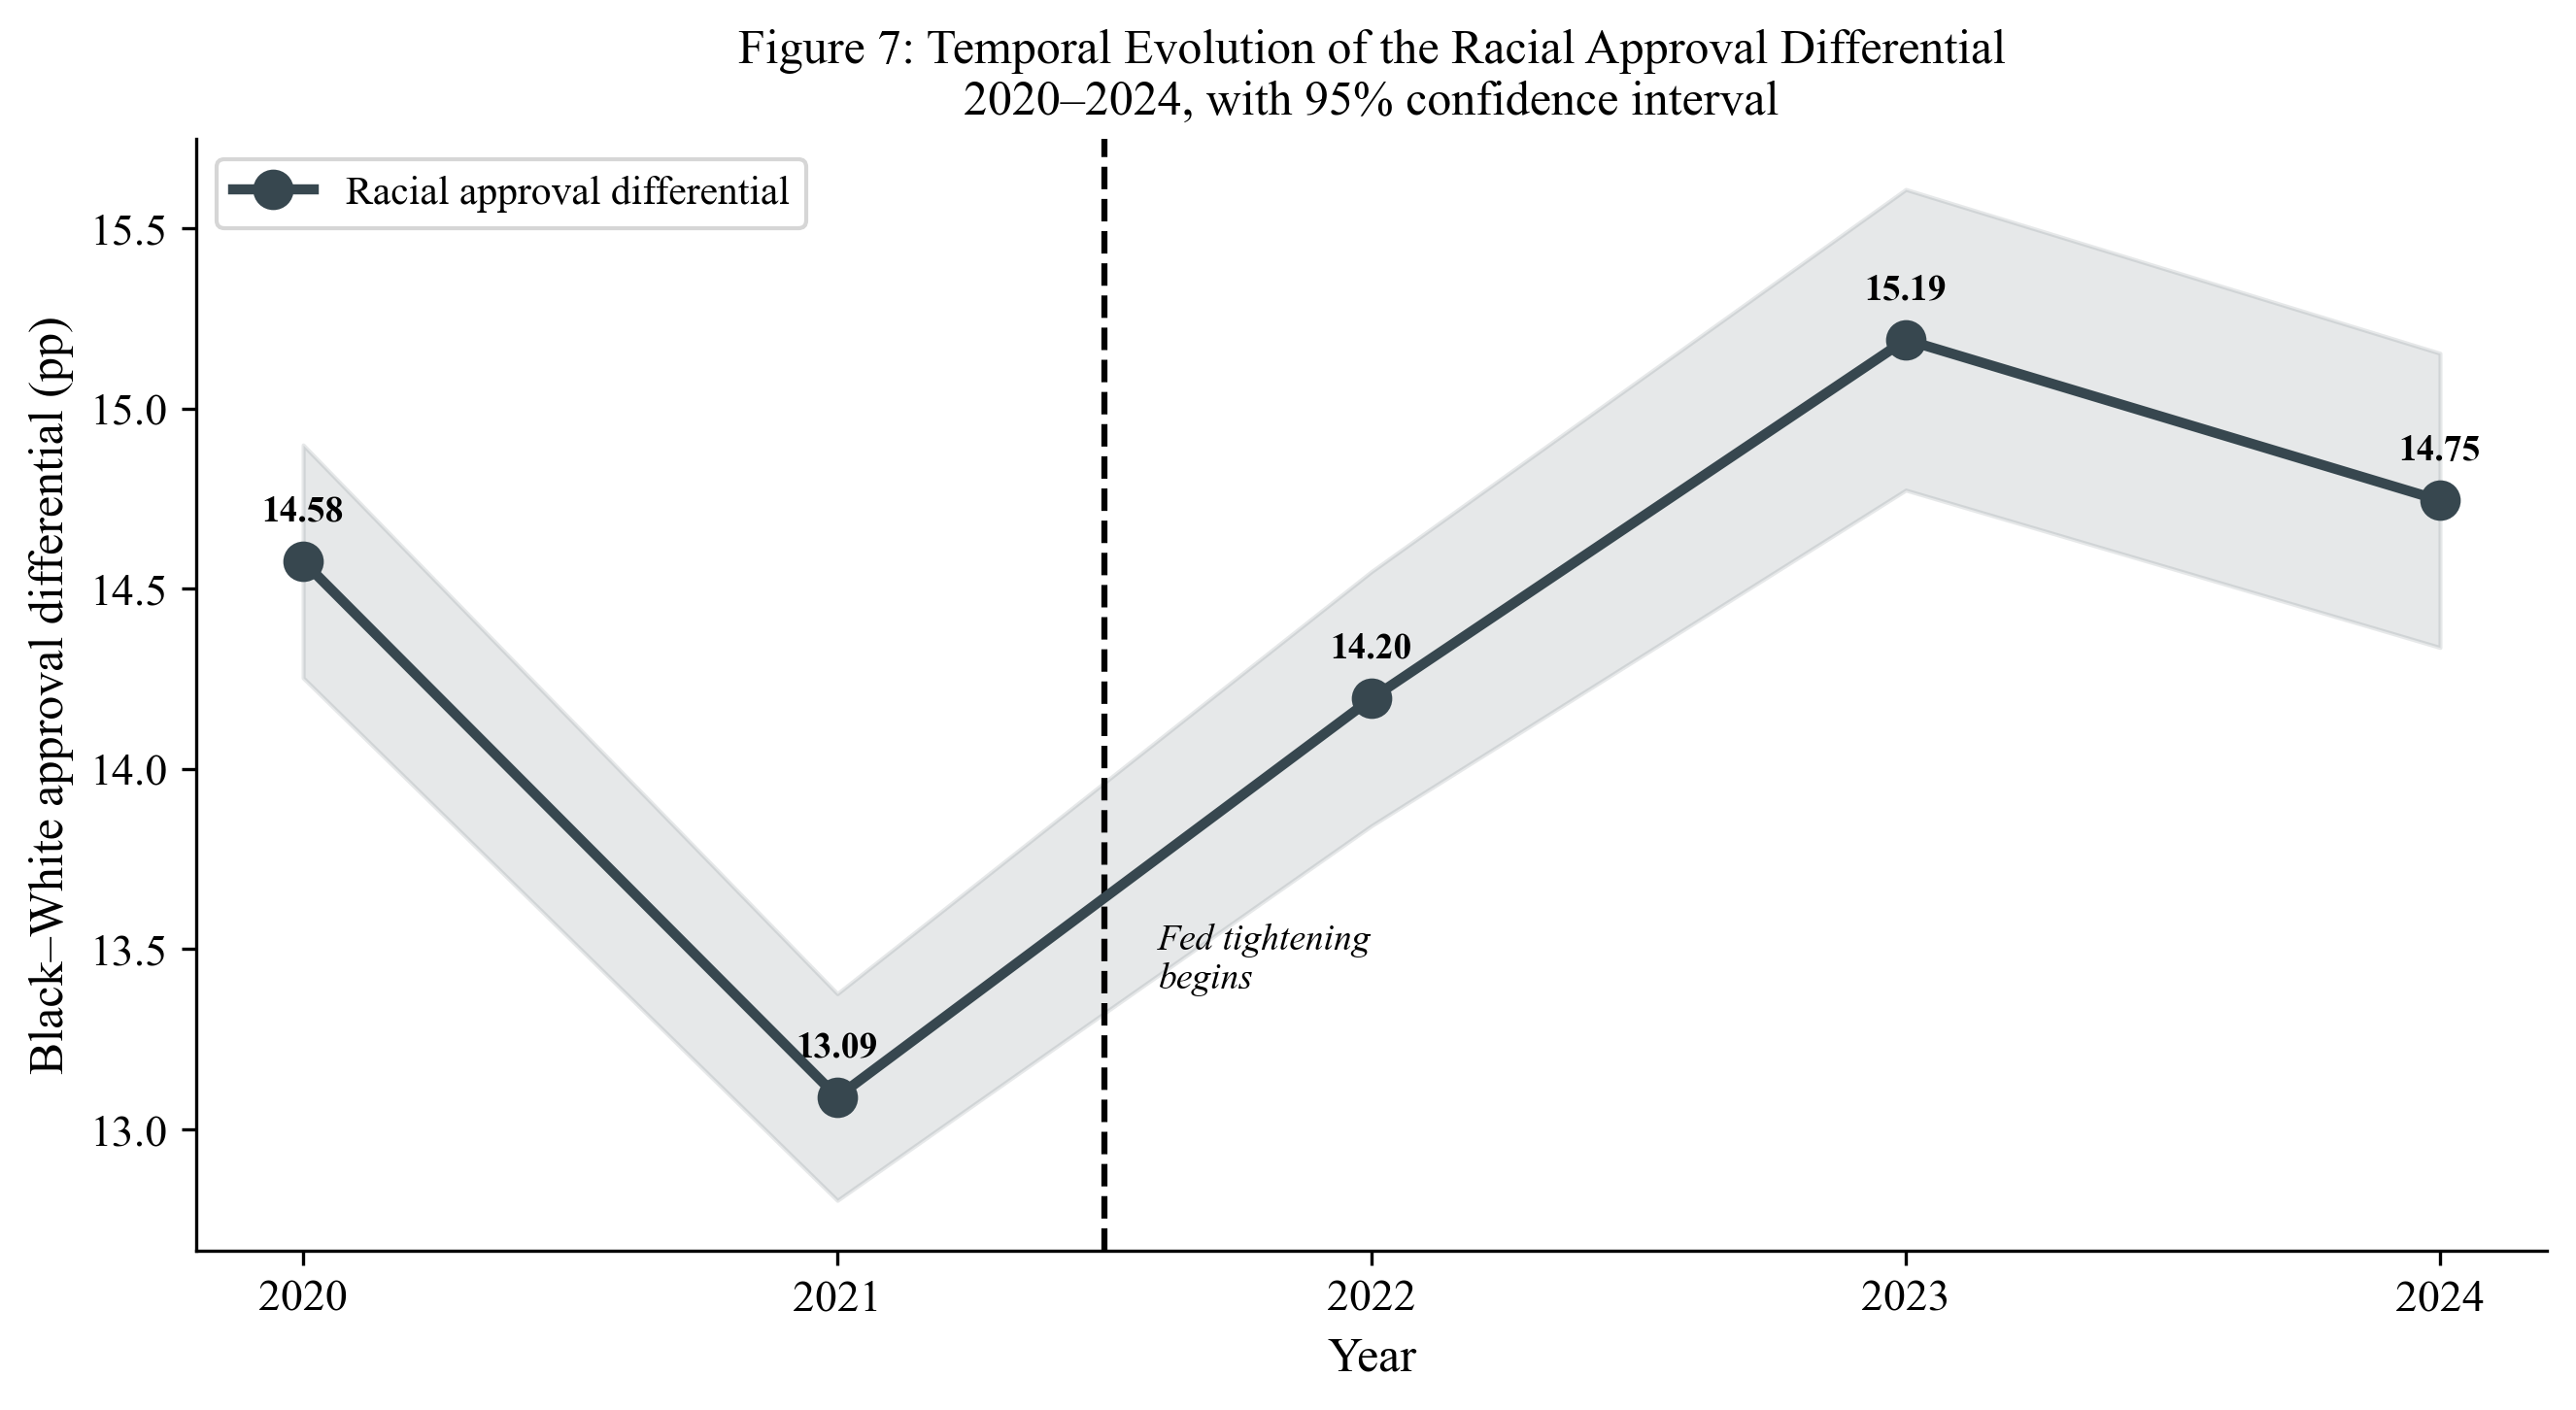

Saved: paper_fig7_temporal.png


In [7]:
# CELL 7 - FIGURE 6: AUS MECHANISM + FIGURE 7: TEMPORAL
print('Generating Figures 6 and 7...')

# ── Figure 6: AUS mechanism from subgroup table ────────────────────────────
if cate_subgroups is not None:
    aus_rows = cate_subgroups[cate_subgroups['subgroup'].str.contains('AUS|automated|manual|exempt', case=False, na=False)]
    income_rows = cate_subgroups[cate_subgroups['subgroup'].str.contains('Income Q', na=False)]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

    # Left: AUS comparison across income groups
    ax = axes[0]
    if len(aus_rows) >= 2:
        aus_labels  = aus_rows['subgroup'].values
        aus_cates   = aus_rows['mean_cate'].values
        aus_ses     = aus_rows['se'].values
        aus_colors  = [ACCENT1 if 'manual' in l.lower() or 'exempt' in l.lower()
                       else ACCENT2 for l in aus_labels]

        bars = ax.bar(range(len(aus_rows)), aus_cates,
                      color=aus_colors, alpha=0.85, width=0.5)
        ax.errorbar(range(len(aus_rows)), aus_cates,
                    yerr=1.96*aus_ses,
                    fmt='none', color='black', capsize=5, linewidth=1.5)
        ax.set_xticks(range(len(aus_rows)))
        ax.set_xticklabels(aus_labels, fontsize=10)
        for i, (v, s) in enumerate(zip(aus_cates, aus_ses)):
            ax.text(i, v - 0.5, f'{v:.2f} pp',
                    ha='center', va='top', fontsize=10, fontweight='bold',
                    color='white')
        ax.set_ylabel('Mean CATE (pp)', fontsize=11)
        ax.set_title('Figure 6A: The AUS Mechanism\n'
                     'Automated vs manual underwriting CATE comparison', fontsize=11)

    # Right: Income gradient
    ax = axes[1]
    if len(income_rows) > 0:
        inc_order = sorted(income_rows['subgroup'].tolist())
        income_rows = income_rows.set_index('subgroup').reindex(inc_order).reset_index()
        ax.bar(range(len(income_rows)), income_rows['mean_cate'],
               color=ACCENT2, alpha=0.82, width=0.6)
        ax.errorbar(range(len(income_rows)), income_rows['mean_cate'],
                    yerr=1.96*income_rows['se'],
                    fmt='none', color='black', capsize=5, linewidth=1.5)
        ax.set_xticks(range(len(income_rows)))
        ax.set_xticklabels(income_rows['subgroup'], fontsize=9)
        overall_m = float(cate_summary['cate_mean_pp'].values[0]) if cate_summary is not None else -9.08
        ax.axhline(overall_m, color='black', linewidth=1.2, linestyle='--',
                   label=f'Overall mean ({overall_m:.2f} pp)')
        ax.set_ylabel('Mean CATE (pp)', fontsize=11)
        ax.set_title('Figure 6B: Income Gradient\n'
                     'Mean conditional differential by income quintile', fontsize=11)
        ax.legend(fontsize=9)

    plt.suptitle('Figure 6: Mechanisms — AUS Type and Income\n', fontsize=12, y=1.01)
    plt.tight_layout()
    out = PAPER_DIR / 'paper_fig6_aus_mechanism.png'
    plt.savefig(out, dpi=300)
    plt.show()
    print(f'Saved: {out.name}')

# ── Figure 7: Temporal evolution ───────────────────────────────────────────
if event_study is not None:
    fig, ax = plt.subplots(figsize=(9, 5))
    years = event_study['year'].values
    gaps  = event_study['gap'].values
    ses   = event_study['se'].values

    ax.plot(years, gaps, 'o-', color=NEUTRAL, linewidth=2.5,
            markersize=9, zorder=5, label='Racial approval differential')
    ax.fill_between(years, gaps - 1.96*ses, gaps + 1.96*ses,
                    alpha=0.12, color=NEUTRAL)

    ax.axvline(2021.5, color='black', linewidth=1.5, linestyle='--')
    ax.text(2021.6, min(gaps) + 0.3, 'Fed tightening\nbegins',
            fontsize=9, style='italic')

    for year, gap in zip(years, gaps):
        ax.annotate(f'{gap:.2f}', xy=(year, gap), xytext=(0, 10),
                    textcoords='offset points', ha='center',
                    fontsize=9, fontweight='bold')

    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel('Black–White approval differential (pp)', fontsize=12)
    ax.set_title('Figure 7: Temporal Evolution of the Racial Approval Differential\n'
                 '2020–2024, with 95% confidence interval', fontsize=12)
    ax.set_xticks(years)
    ax.legend(fontsize=10)

    plt.tight_layout()
    out = PAPER_DIR / 'paper_fig7_temporal.png'
    plt.savefig(out, dpi=300)
    plt.show()
    print(f'Saved: {out.name}')

In [8]:
# CELL 8 - APPENDIX FIGURE: OVERLAP DIAGNOSTIC
print('Generating Appendix: Overlap Diagnostic...')

# Copy existing NB18 overlap plot to paper figures folder at 300 DPI
src = FIGURES_DIR / 'nb18_overlap_plot.png'
if src.exists():
    dst = PAPER_DIR / 'paper_appendix_overlap.png'
    shutil.copy2(str(src), str(dst))
    print(f'Copied: {dst.name}')
else:
    print('nb18_overlap_plot.png not found — run NB18 first')

# List all paper figures created
print('\n' + '='*70)
print('ALL PAPER FIGURES')
print('='*70)
paper_figs = sorted(PAPER_DIR.glob('*.png'))
total_size = sum(f.stat().st_size for f in paper_figs) / 1e6
for f in paper_figs:
    size_kb = f.stat().st_size / 1e3
    print(f'  {f.name:<45} {size_kb:.0f} KB')
print(f'Total: {len(paper_figs)} figures, {total_size:.1f} MB')

Generating Appendix: Overlap Diagnostic...
Copied: paper_appendix_overlap.png

ALL PAPER FIGURES
  paper_appendix_overlap.png                    85 KB
  paper_fig1_ate_summary.png                    169 KB
  paper_fig2_cate_distribution.png              268 KB
  paper_fig3_subgroup_results.png               240 KB
  paper_fig4_shap_attribution.png               194 KB
  paper_fig5_disparity_map.png                  350 KB
  paper_fig6_aus_mechanism.png                  150 KB
  paper_fig7_temporal.png                       263 KB
Total: 8 figures, 1.7 MB


In [9]:
# CELL 9 - VERIFICATION AND SUMMARY STATISTICS TABLE
print('='*70)
print('VERIFICATION')
print('='*70)

required_figs = [
    'paper_fig1_ate_summary.png',
    'paper_fig2_cate_distribution.png',
    'paper_fig3_subgroup_results.png',
    'paper_fig4_shap_attribution.png',
    'paper_fig5_disparity_map.png',
    'paper_fig6_aus_mechanism.png',
    'paper_fig7_temporal.png',
]
missing = []
for f in required_figs:
    p = PAPER_DIR / f
    if p.exists():
        print(f'  {f}: OK ({p.stat().st_size//1024} KB)')
    else:
        print(f'  {f}: MISSING')
        missing.append(f)

# Key numbers summary for paper
print('\n' + '='*70)
print('KEY NUMBERS FOR PAPER')
print('='*70)
cate_pp = cate_df['cate_pp'].values
print(f'Raw gap                 : 14.95 pp (from HMDA 2020-2024)')
print(f'DML ATE (X_FULL)        : -9.39 pp')
print(f'% unexplained by DML    : 62.8% of raw gap')
print(f'CATE mean               : {np.mean(cate_pp):.2f} pp')
print(f'CATE std                : {np.std(cate_pp):.2f} pp')
print(f'CATE P10                : {np.percentile(cate_pp, 10):.2f} pp')
print(f'CATE P90                : {np.percentile(cate_pp, 90):.2f} pp')
print(f'% penalised             : {100*(cate_pp<0).mean():.1f}%')
if shap_imp is not None:
    top_feat = shap_imp.iloc[0]
    name = top_feat.get('display_name', top_feat['feature'])
    print(f'Top SHAP driver         : {name} ({top_feat["mean_abs_shap"]:.3f} pp)')
print(f'NB18 propensity AUC     : 0.729')
print(f'Common support          : 98.0%')

print('\n' + '='*70)
if not missing:
    print('ALL VERIFICATION CHECKS PASSED')
    print('NB26 complete — analysis phase is done')
    print(f'Paper figures in: {PAPER_DIR}')
    print('Next step: write the paper draft')
else:
    print(f'WARNING: {len(missing)} figures missing — re-run relevant notebooks')
print('='*70)

VERIFICATION
  paper_fig1_ate_summary.png: OK (165 KB)
  paper_fig2_cate_distribution.png: OK (261 KB)
  paper_fig3_subgroup_results.png: OK (234 KB)
  paper_fig4_shap_attribution.png: OK (189 KB)
  paper_fig5_disparity_map.png: OK (341 KB)
  paper_fig6_aus_mechanism.png: OK (146 KB)
  paper_fig7_temporal.png: OK (257 KB)

KEY NUMBERS FOR PAPER
Raw gap                 : 14.95 pp (from HMDA 2020-2024)
DML ATE (X_FULL)        : -9.39 pp
% unexplained by DML    : 62.8% of raw gap
CATE mean               : -9.08 pp
CATE std                : 8.47 pp
CATE P10                : -21.19 pp
CATE P90                : -0.16 pp
% penalised             : 90.7%
Top SHAP driver         : Automated underwriting (AUS) (3.139 pp)
NB18 propensity AUC     : 0.729
Common support          : 98.0%

ALL VERIFICATION CHECKS PASSED
NB26 complete — analysis phase is done
Paper figures in: D:\Projects\CATE-HMDA-Heterogeneous-Effects\outputs\paper_figures
Next step: write the paper draft
